In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [104]:
df=pd.read_csv("opensky_states_snapshot.csv")

In [105]:
df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,39de4e,TVF32DD,France,1.755600e+09,1755600237,27.5943,40.9151,3535.68,False,155.44,83.16,-13.98,NaN,3718.56,674.0,False,0
1,39de4b,TVF48LB,France,1.755600e+09,1755600237,2.3048,48.7157,167.64,False,70.45,61.19,-4.23,NaN,220.98,2272.0,False,0
2,39de4a,TVF8393,France,1.755600e+09,1755600238,4.0351,46.5247,10355.58,False,230.22,330.11,-0.33,NaN,10820.40,1000.0,False,0
3,39de4d,TVF17HP,France,1.755600e+09,1755600182,-7.7757,32.6880,11887.20,False,237.76,212.45,-0.33,NaN,12649.20,7616.0,False,0
4,aa9321,UAL803,United States,1.755600e+09,1755600238,140.1061,35.9174,2202.18,False,142.66,182.69,-2.93,NaN,2392.68,3242.0,False,0


In [106]:
df.shape

(7420, 17)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7420 entries, 0 to 7419
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   icao24           7420 non-null   object 
 1   callsign         7284 non-null   object 
 2   origin_country   7420 non-null   object 
 3   time_position    7359 non-null   float64
 4   last_contact     7420 non-null   int64  
 5   longitude        7359 non-null   float64
 6   latitude         7359 non-null   float64
 7   baro_altitude    6815 non-null   float64
 8   on_ground        7420 non-null   bool   
 9   velocity         7418 non-null   float64
 10  true_track       7420 non-null   float64
 11  vertical_rate    6836 non-null   float64
 12  sensors          0 non-null      float64
 13  geo_altitude     6719 non-null   float64
 14  squawk           4550 non-null   float64
 15  spi              7420 non-null   bool   
 16  position_source  7420 non-null   int64  
dtypes: bool(2), fl

In [108]:
df.describe()

,time_position,last_contact,longitude,latitude,baro_altitude,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,position_source
count,7.359000e+03,7.420000e+03,7359.000000,7359.000000,6815.000000,7418.000000,7420.000000,6836.000000,0.0,6719.000000,4550.000000,7420.0
mean,1.755600e+09,1.755600e+09,5.355736,37.429213,7250.561379,171.656301,186.871735,-0.012267,NaN,7649.898208,3639.561099,0.0
std,2.150259e+02,5.471254e+01,65.096936,18.789600,4238.752990,84.004967,103.300060,5.114121,NaN,4395.965824,2346.162327,0.0
min,1.755593e+09,1.755600e+09,-173.897800,-54.961800,-121.920000,0.000000,0.000000,-47.140000,NaN,-30.480000,2.000000,0.0
25%,1.755600e+09,1.755600e+09,-13.090900,34.736000,2895.600000,104.350000,99.702500,-0.330000,NaN,3166.110000,1270.250000,0.0
50%,1.755600e+09,1.755600e+09,7.620700,41.432500,9105.900000,211.360000,190.285000,0.000000,NaN,9601.200000,3414.500000,0.0
75%,1.755600e+09,1.755600e+09,25.293950,48.572600,10972.800000,236.610000,281.250000,0.330000,NaN,11414.760000,5665.000000,0.0
max,1.755600e+09,1.755600e+09,174.808900,70.017200,21061.680000,1241.070000,359.770000,29.910000,NaN,21046.440000,7777.000000,0.0


In [109]:
df.columns

Index(['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact',
       'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity',
       'true_track', 'vertical_rate', 'sensors', 'geo_altitude', 'squawk',
       'spi', 'position_source'],
      dtype='object')

In [110]:
df.isnull().sum()

icao24                0
callsign            136
origin_country        0
time_position        61
last_contact          0
longitude            61
latitude             61
baro_altitude       605
on_ground             0
velocity              2
true_track            0
vertical_rate       584
sensors            7420
geo_altitude        701
squawk             2870
spi                   0
position_source       0
dtype: int64

observations :
1. there are 7420 data rows
2. columns needed for trajectory prediction and anomaly detection: longitude , latitude, baro_altitude, geo_altitude, velocity, true track, vertical_rate, time_Position, last_contact
3. columns useful for classification and risk preditiction : origin_country, on_ground, squawk, callsign, icao24
4. columns which are safe o drop : sensors, spi , position_source


In [111]:
# 1. Fill Categorical/Text nulls first
df['callsign'] = df['callsign'].fillna('UNKNOWN')
df['squawk'] = df['squawk'].fillna('0000')
df['origin_country'] = df['origin_country'].fillna('Unknown')

# 2. Fill Kinematic nulls (The "Safety Net" approach)
# We try to fill based on the plane's history, then fill any remaining with 0
df['baro_altitude'] = df.groupby('icao24')['baro_altitude'].ffill().bfill().fillna(0)
df['velocity'] = df.groupby('icao24')['velocity'].ffill().bfill().fillna(0)
df['vertical_rate'] = df.groupby('icao24')['vertical_rate'].ffill().bfill().fillna(0)
df['true_track'] = df.groupby('icao24')['true_track'].ffill().bfill().fillna(0)

# 3. Handle Booleans
df['on_ground'] = df['on_ground'].fillna(False)

# 4. Drop the "Unfixable" (If we don't have Lat/Lon, we can't map it)
df.dropna(subset=['latitude', 'longitude'], inplace=True)

df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,39de4e,TVF32DD,France,1.755600e+09,1755600237,27.5943,40.9151,3535.68,False,155.44,83.16,-13.98,NaN,3718.56,674.0,False,0
1,39de4b,TVF48LB,France,1.755600e+09,1755600237,2.3048,48.7157,167.64,False,70.45,61.19,-4.23,NaN,220.98,2272.0,False,0
2,39de4a,TVF8393,France,1.755600e+09,1755600238,4.0351,46.5247,10355.58,False,230.22,330.11,-0.33,NaN,10820.40,1000.0,False,0
3,39de4d,TVF17HP,France,1.755600e+09,1755600182,-7.7757,32.6880,11887.20,False,237.76,212.45,-0.33,NaN,12649.20,7616.0,False,0
4,aa9321,UAL803,United States,1.755600e+09,1755600238,140.1061,35.9174,2202.18,False,142.66,182.69,-2.93,NaN,2392.68,3242.0,False,0


In [112]:
df.shape

(7359, 17)

In [113]:
df.drop(columns=['spi', 'position_source','sensors'],inplace=True)

In [114]:
# Fill geo_altitude using baro_altitude where it's missing
df['geo_altitude'] = df['geo_altitude'].fillna(df['baro_altitude'])

# If any are still null (meaning both were null), fill with 0
df['geo_altitude'] = df['geo_altitude'].fillna(0)

In [115]:
df.isnull().sum()

icao24            0
callsign          0
origin_country    0
time_position     0
last_contact      0
longitude         0
latitude          0
baro_altitude     0
on_ground         0
velocity          0
true_track        0
vertical_rate     0
geo_altitude      0
squawk            0
dtype: int64

In [116]:
df.duplicated().value_counts()

False    7359
Name: count, dtype: int64

there are 0 null values in dataset and no duplicates . 
now we will check features dependency using various graphs

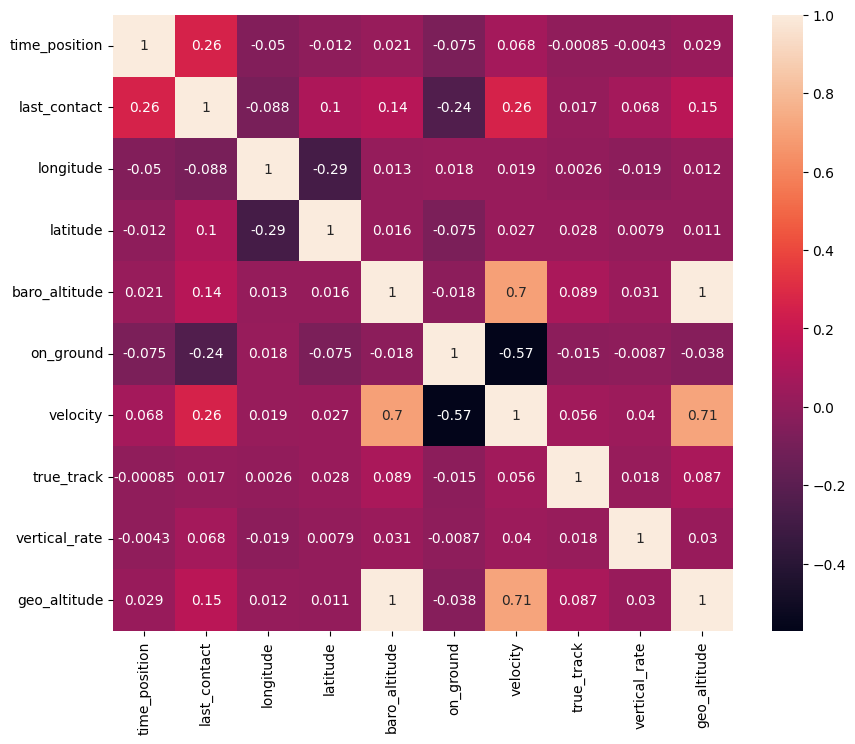

In [117]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

Insights:
1. here is a strong positive correlation between baro_altitude and velocity.
2. Baro vs. Geo Altitude (1 correlation): These are nearly identical.
3. Vertical Rate & Others ( 0.03 correlation): vertical_rate is independent of almost everything else.
Because it is independent, vertical_rate is your most important feature for detecting "Erratic Behavior" (Objective 3).

In [118]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

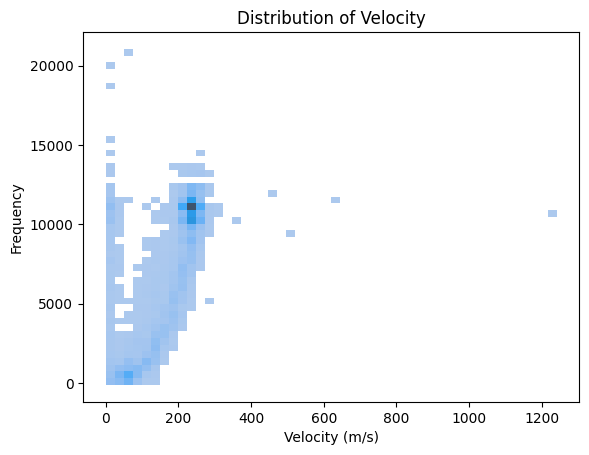

In [119]:
sns.histplot(x=df['velocity'], y=df['baro_altitude'], bins=50, kde=True)
plt.title('Distribution of Velocity')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Frequency')
plt.show()

Insights :
1. The "Cruise" Hotspot: a high-density cluster (the darkest area) between 200-250 m/s velocity and 9,000-11,000 meters altitude. 
This represents the stable cruising phase of commercial aircraft. This is your "Normal" baseline for the monitoring system.
2. The "Takeoff/Landing" Tail: A diagonal line of data points extending from $(0,0)$ toward the cruise hotspot.
This shows the transition phase. Objects in this zone are changing states. If an object is in this zone but has no callsign, it is a high-probability candidate for a Drone or Unidentified Object.
3. Empty Zones (The "Forbidden" Airspace): Notice the empty areas (e.g., extremely high speed at low altitude).
Commercial planes cannot physically fly at 1000 m/s at sea level due to air density. Any data point appearing in these empty regions in the future should be flagged by your Anomaly Detection as a "Physics Violation" or "Sensor Error."

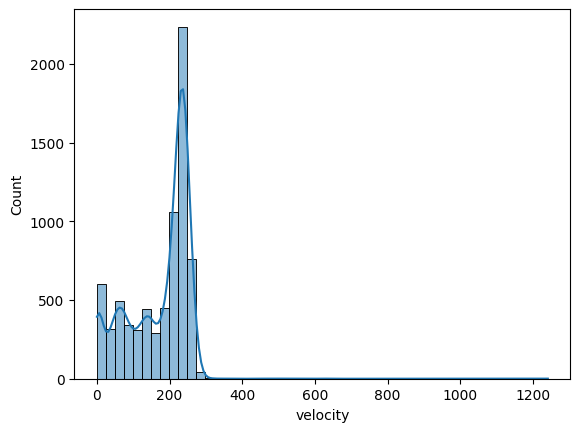

In [120]:
sns.histplot(df['velocity'], bins=50, kde=True)
plt.show()

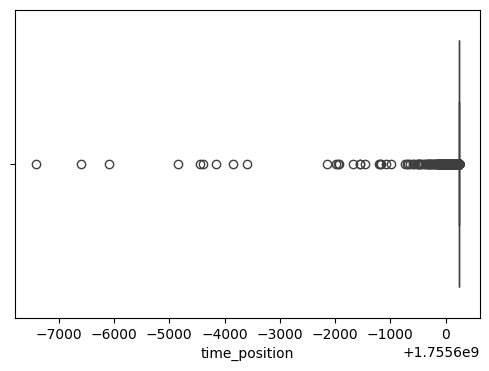

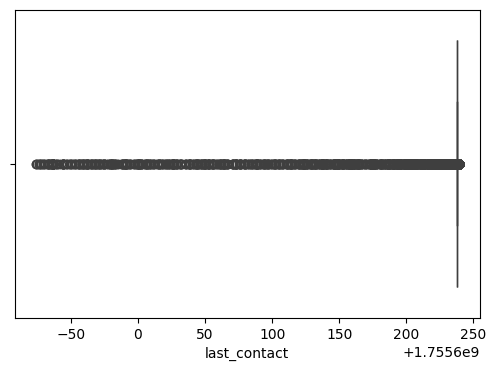

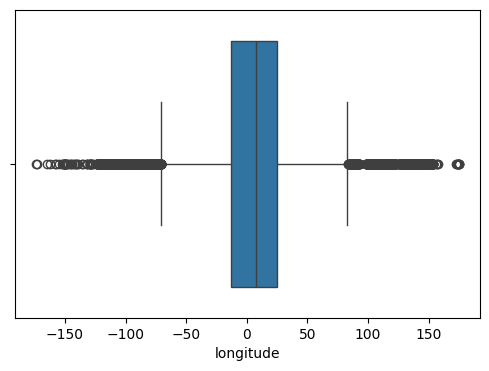

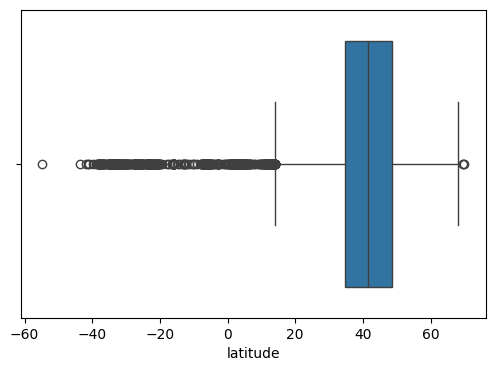

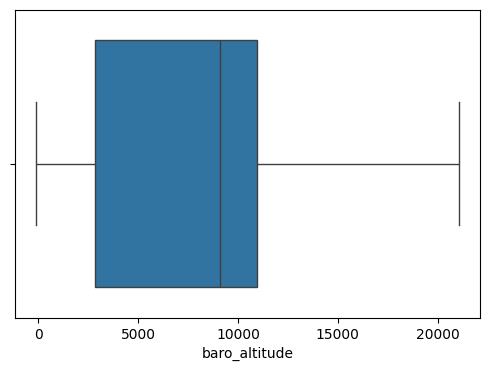

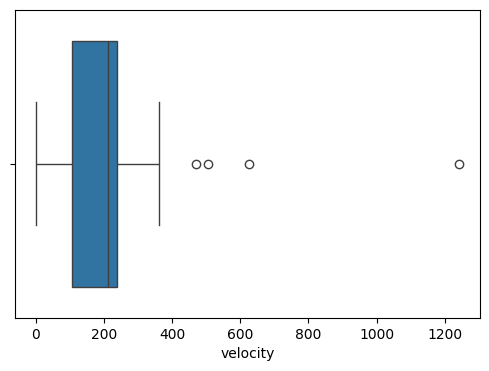

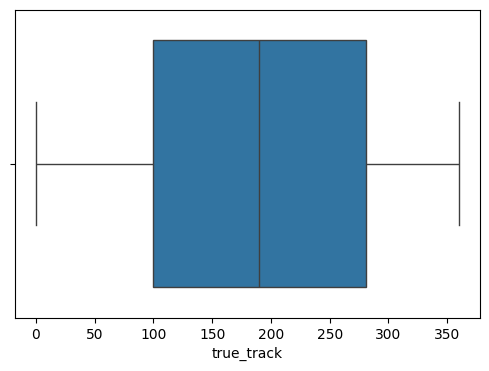

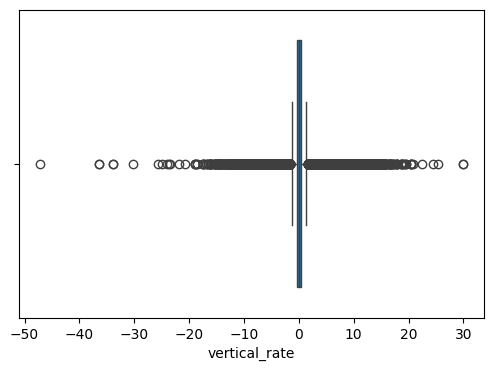

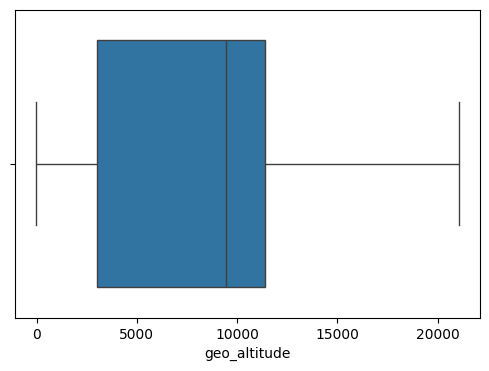

In [121]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.show()

Insights: 
1. Velocity Outliers: data has a maximum velocity of $1241$ m/s, while the 75th percentile is only 236 m/s.
hese extreme outliers represent supersonic movement. In a real-world system, these would be flagged as military aircraft or sensor errors.
2. Vertical Rate Outliers ($2,996$ outliers detected): we have a massive number of points outside the typical box.
This suggests your dataset contains many flights that are in "active phases" (climbing or descending) rather than just cruising. For your Risk Assessment, any vertical rate exceeding $\pm 15$ m/s should trigger an "Abrupt Maneuver" alert.
3. Altitude Distribution: The "box" (25th to 75th percentile) sits between $2,800$m and $10,900$m.
Objects below the bottom whisker ($< 500$m) are your primary candidates for Drones and Birds

In [122]:
df_cleaned=df.copy()

In [123]:
df_cleaned.columns

Index(['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact',
       'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity',
       'true_track', 'vertical_rate', 'geo_altitude', 'squawk'],
      dtype='object')

In [124]:
print(numeric_columns)

Index(['time_position', 'last_contact', 'longitude', 'latitude',
       'baro_altitude', 'velocity', 'true_track', 'vertical_rate',
       'geo_altitude'],
      dtype='object')


In [125]:
cat_columns = df_cleaned.select_dtypes(include=['object', 'bool']).columns
df_cleaned[cat_columns]

,icao24,callsign,origin_country,on_ground,squawk
0,39de4e,TVF32DD,France,False,674.0
1,39de4b,TVF48LB,France,False,2272.0
2,39de4a,TVF8393,France,False,1000.0
3,39de4d,TVF17HP,France,False,7616.0
4,aa9321,UAL803,United States,False,3242.0
...,...,...,...,...,...
7415,a7e509,DAL2953,United States,False,1036.0
7416,a4359b,UPS982,United States,False,6671.0
7417,4b1901,EDW76,Switzerland,False,1601.0
7418,4caa32,ITY614,Ireland,False,5771.0


In [126]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['origin_country'], drop_first=True )

In [127]:
df_cleaned

,icao24,callsign,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,...,origin_country_Turkey,origin_country_Uganda,origin_country_Ukraine,origin_country_United Arab Emirates,origin_country_United Kingdom,origin_country_United Republic of Tanzania,origin_country_United States,origin_country_Uzbekistan,origin_country_Viet Nam,origin_country_Zambia
0,39de4e,TVF32DD,1.755600e+09,1755600237,27.5943,40.9151,3535.68,False,155.44,83.16,...,False,False,False,False,False,False,False,False,False,False
1,39de4b,TVF48LB,1.755600e+09,1755600237,2.3048,48.7157,167.64,False,70.45,61.19,...,False,False,False,False,False,False,False,False,False,False
2,39de4a,TVF8393,1.755600e+09,1755600238,4.0351,46.5247,10355.58,False,230.22,330.11,...,False,False,False,False,False,False,False,False,False,False
3,39de4d,TVF17HP,1.755600e+09,1755600182,-7.7757,32.6880,11887.20,False,237.76,212.45,...,False,False,False,False,False,False,False,False,False,False
4,aa9321,UAL803,1.755600e+09,1755600238,140.1061,35.9174,2202.18,False,142.66,182.69,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7415,a7e509,DAL2953,1.755600e+09,1755600238,-83.7152,33.0894,5867.40,False,209.21,318.59,...,False,False,False,False,False,False,True,False,False,False
7416,a4359b,UPS982,1.755600e+09,1755600239,-93.6074,39.6754,10370.82,False,234.21,296.62,...,False,False,False,False,False,False,True,False,False,False
7417,4b1901,EDW76,1.755600e+09,1755600228,27.8660,30.4635,10668.00,False,252.60,141.45,...,False,False,False,False,False,False,False,False,False,False
7418,4caa32,ITY614,1.755600e+09,1755600239,3.6458,49.0758,11582.40,False,255.81,321.29,...,False,False,False,False,False,False,False,False,False,False


In [128]:
df_cleaned = df_cleaned.drop(['icao24', 'callsign'], axis=1)
df_cleaned.head()

,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,...,origin_country_Turkey,origin_country_Uganda,origin_country_Ukraine,origin_country_United Arab Emirates,origin_country_United Kingdom,origin_country_United Republic of Tanzania,origin_country_United States,origin_country_Uzbekistan,origin_country_Viet Nam,origin_country_Zambia
0,1.755600e+09,1755600237,27.5943,40.9151,3535.68,False,155.44,83.16,-13.98,3718.56,...,False,False,False,False,False,False,False,False,False,False
1,1.755600e+09,1755600237,2.3048,48.7157,167.64,False,70.45,61.19,-4.23,220.98,...,False,False,False,False,False,False,False,False,False,False
2,1.755600e+09,1755600238,4.0351,46.5247,10355.58,False,230.22,330.11,-0.33,10820.40,...,False,False,False,False,False,False,False,False,False,False
3,1.755600e+09,1755600182,-7.7757,32.6880,11887.20,False,237.76,212.45,-0.33,12649.20,...,False,False,False,False,False,False,False,False,False,False
4,1.755600e+09,1755600238,140.1061,35.9174,2202.18,False,142.66,182.69,-2.93,2392.68,...,False,False,False,False,False,False,True,False,False,False


In [129]:
df_cleaned["time_position"] = pd.to_datetime(df_cleaned["time_position"], unit="s")
df_cleaned["last_contact"] = pd.to_datetime(df_cleaned["last_contact"], unit="s")
df_cleaned.dtypes

time_position                                 datetime64[ns]
last_contact                                  datetime64[ns]
longitude                                            float64
latitude                                             float64
baro_altitude                                        float64
                                                   ...      
origin_country_United Republic of Tanzania              bool
origin_country_United States                            bool
origin_country_Uzbekistan                               bool
origin_country_Viet Nam                                 bool
origin_country_Zambia                                   bool
Length: 112, dtype: object

In [130]:
df_cleaned.to_csv("dashboard_dataset.csv", index=False)

In [131]:
df_cleaned

,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,...,origin_country_Turkey,origin_country_Uganda,origin_country_Ukraine,origin_country_United Arab Emirates,origin_country_United Kingdom,origin_country_United Republic of Tanzania,origin_country_United States,origin_country_Uzbekistan,origin_country_Viet Nam,origin_country_Zambia
0,2025-08-19 10:43:54,2025-08-19 10:43:57,27.5943,40.9151,3535.68,False,155.44,83.16,-13.98,3718.56,...,False,False,False,False,False,False,False,False,False,False
1,2025-08-19 10:43:56,2025-08-19 10:43:57,2.3048,48.7157,167.64,False,70.45,61.19,-4.23,220.98,...,False,False,False,False,False,False,False,False,False,False
2,2025-08-19 10:43:58,2025-08-19 10:43:58,4.0351,46.5247,10355.58,False,230.22,330.11,-0.33,10820.40,...,False,False,False,False,False,False,False,False,False,False
3,2025-08-19 10:43:02,2025-08-19 10:43:02,-7.7757,32.6880,11887.20,False,237.76,212.45,-0.33,12649.20,...,False,False,False,False,False,False,False,False,False,False
4,2025-08-19 10:43:58,2025-08-19 10:43:58,140.1061,35.9174,2202.18,False,142.66,182.69,-2.93,2392.68,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7415,2025-08-19 10:43:58,2025-08-19 10:43:58,-83.7152,33.0894,5867.40,False,209.21,318.59,-11.05,6233.16,...,False,False,False,False,False,False,True,False,False,False
7416,2025-08-19 10:43:58,2025-08-19 10:43:59,-93.6074,39.6754,10370.82,False,234.21,296.62,0.00,11018.52,...,False,False,False,False,False,False,True,False,False,False
7417,2025-08-19 10:43:33,2025-08-19 10:43:48,27.8660,30.4635,10668.00,False,252.60,141.45,0.00,11445.24,...,False,False,False,False,False,False,False,False,False,False
7418,2025-08-19 10:43:58,2025-08-19 10:43:59,3.6458,49.0758,11582.40,False,255.81,321.29,0.00,12031.98,...,False,False,False,False,False,False,False,False,False,False


In [132]:
ml_df = df_cleaned.copy()

In [133]:
ml_df

,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,...,origin_country_Turkey,origin_country_Uganda,origin_country_Ukraine,origin_country_United Arab Emirates,origin_country_United Kingdom,origin_country_United Republic of Tanzania,origin_country_United States,origin_country_Uzbekistan,origin_country_Viet Nam,origin_country_Zambia
0,2025-08-19 10:43:54,2025-08-19 10:43:57,27.5943,40.9151,3535.68,False,155.44,83.16,-13.98,3718.56,...,False,False,False,False,False,False,False,False,False,False
1,2025-08-19 10:43:56,2025-08-19 10:43:57,2.3048,48.7157,167.64,False,70.45,61.19,-4.23,220.98,...,False,False,False,False,False,False,False,False,False,False
2,2025-08-19 10:43:58,2025-08-19 10:43:58,4.0351,46.5247,10355.58,False,230.22,330.11,-0.33,10820.40,...,False,False,False,False,False,False,False,False,False,False
3,2025-08-19 10:43:02,2025-08-19 10:43:02,-7.7757,32.6880,11887.20,False,237.76,212.45,-0.33,12649.20,...,False,False,False,False,False,False,False,False,False,False
4,2025-08-19 10:43:58,2025-08-19 10:43:58,140.1061,35.9174,2202.18,False,142.66,182.69,-2.93,2392.68,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7415,2025-08-19 10:43:58,2025-08-19 10:43:58,-83.7152,33.0894,5867.40,False,209.21,318.59,-11.05,6233.16,...,False,False,False,False,False,False,True,False,False,False
7416,2025-08-19 10:43:58,2025-08-19 10:43:59,-93.6074,39.6754,10370.82,False,234.21,296.62,0.00,11018.52,...,False,False,False,False,False,False,True,False,False,False
7417,2025-08-19 10:43:33,2025-08-19 10:43:48,27.8660,30.4635,10668.00,False,252.60,141.45,0.00,11445.24,...,False,False,False,False,False,False,False,False,False,False
7418,2025-08-19 10:43:58,2025-08-19 10:43:59,3.6458,49.0758,11582.40,False,255.81,321.29,0.00,12031.98,...,False,False,False,False,False,False,False,False,False,False


In [134]:
bool_cols = ml_df.select_dtypes(include="bool").columns
ml_df[bool_cols] = ml_df[bool_cols].astype(int)

In [135]:
ml_df = ml_df.drop([
"time_position",
"last_contact"
], axis=1)

In [136]:
ml_df["speed_change"] = ml_df["velocity"].diff()
ml_df["altitude_change"] = ml_df["geo_altitude"].diff()

In [137]:
ml_df = ml_df.fillna(0)

In [138]:
ml_df.dtypes

longitude                    float64
latitude                     float64
baro_altitude                float64
on_ground                      int64
velocity                     float64
                              ...   
origin_country_Uzbekistan      int64
origin_country_Viet Nam        int64
origin_country_Zambia          int64
speed_change                 float64
altitude_change              float64
Length: 112, dtype: object

In [139]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [140]:
ml_df.to_csv("ml_dataset.csv", index=False)

In [141]:
# Statistical Test for Normality

from scipy.stats import shapiro

# Testing velocity for normality
stat, p = shapiro(ml_df['velocity'])
print(f'Velocity Normality Test: p-value={p:.4f}')
if p > 0.05:
    print("Data looks Gaussian (Normal)")
else:
    print("Data does not look Gaussian (Use Non-Parametric Models)")

Velocity Normality Test: p-value=0.0000
Data does not look Gaussian (Use Non-Parametric Models)


a Shapiro-Wilk Normality Test which yielded a p-value of 0. This statistically proves our data is non-Gaussian, justifying our choice to use Non-Parametric ML models like Random Forest and Isolation Forest, which do not require the data to be normally distributed.